# Lab 10: Numerical Differentiation & Integration

## Examples (by instructor)

In this lab you will practice the numerical tools from Chapter 15:

| Task | Tool | Key syntax |
|------|------|-----------|
| Derivative of discrete data | `np.gradient` | `np.gradient(y, x)` |
| Integral of discrete data | `scipy.integrate.trapezoid` | `trapezoid(y, x)` |
| Integral of a Python function | `scipy.integrate.quad` | `result, err = quad(f, a, b)` |

### Example 1: Reaction Rate from Concentration Data (`np.gradient`)

In a batch reactor experiment, species A is consumed over time. We measure $C_A$ at discrete time points and compute the reaction rate of disappearance:

$$r_A = -\frac{dC_A}{dt}$$

`np.gradient` uses central differences at interior points and one-sided differences at the endpoints — automatically handling non-uniform spacing.

 t (s)   C_A (mol/L)   r_A (mol/L·s)
--------------------------------------
     0          1.00          0.0220
    10          0.78          0.0195
    20          0.61          0.0150
    30          0.48          0.0120
    40          0.37          0.0095
    50          0.29          0.0070
    60          0.23          0.0060


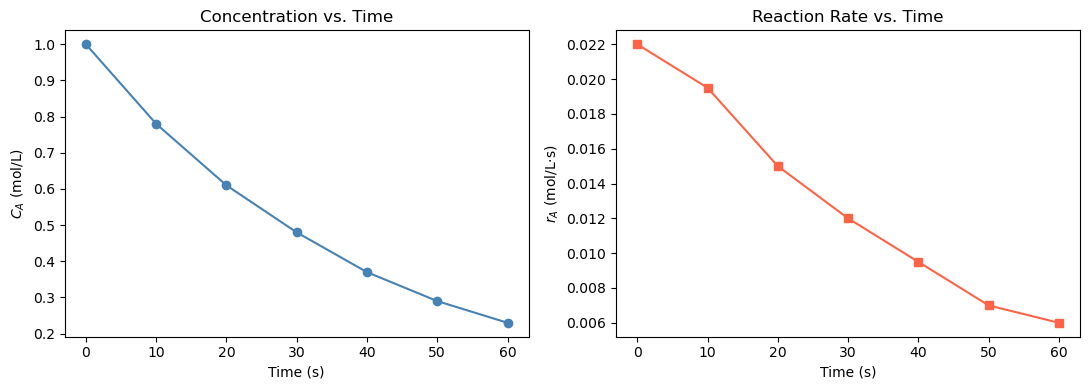

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid

t   = np.array([0,    10,   20,   30,   40,   50,   60  ])  # s
C_A = np.array([1.00, 0.78, 0.61, 0.48, 0.37, 0.29, 0.23])  # mol/L

# Reaction rate: r_A = -dC_A/dt
r_A = -np.gradient(C_A, t)

print(f"{'t (s)':>6}  {'C_A (mol/L)':>12}  {'r_A (mol/L·s)':>14}")
print("-" * 38)
for i in range(len(t)):
    print(f"  {t[i]:>4.0f}  {C_A[i]:>12.2f}  {r_A[i]:>14.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(t, C_A, 'o-', color='steelblue')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('$C_A$ (mol/L)')
axes[0].set_title('Concentration vs. Time')

axes[1].plot(t, r_A, 's-', color='tomato')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('$r_A$ (mol/L·s)')
axes[1].set_title('Reaction Rate vs. Time')
plt.tight_layout(); plt.show()

### Example 2: Heat Required from Tabulated $C_p$ Data (`trapezoid`)

A steam process requires heating from 400 K to 1000 K. Given tabulated heat capacity values, compute the enthalpy change:

$$\Delta H = \int_{400}^{1000} C_p(T) \, dT$$

`trapezoid(y, x)` connects adjacent data points with straight lines and sums the trapezoidal areas. Always pass `x` as the second argument — omitting it assumes unit spacing and gives the wrong answer when your x-axis has physical units.

ΔH = ∫Cp dT = 22485.0 J/mol = 22.485 kJ/mol


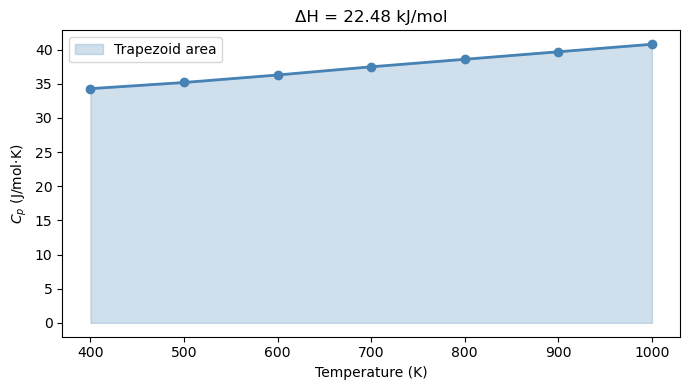

In [2]:
# Tabulated Cp data for steam (J/mol·K)
T_data  = np.array([400,  500,  600,  700,  800,  900,  1000])  # K
Cp_data = np.array([34.3, 35.2, 36.3, 37.5, 38.6, 39.7,  40.8])  # J/mol·K

delta_H = trapezoid(Cp_data, T_data)   # J/mol
print(f"ΔH = ∫Cp dT = {delta_H:.1f} J/mol = {delta_H/1000:.3f} kJ/mol")

fig, ax = plt.subplots(figsize=(7, 4))
T_fine = np.linspace(400, 1000, 300)
ax.fill_between(T_data, Cp_data, alpha=0.25, color='steelblue', label='Trapezoid area')
ax.plot(T_data, Cp_data, 'o-', color='steelblue', linewidth=2)
ax.set_xlabel('Temperature (K)'); ax.set_ylabel('$C_p$ (J/mol·K)')
ax.set_title(f'ΔH = {delta_H/1000:.2f} kJ/mol')
ax.legend(); plt.tight_layout(); plt.show()

---

## Warm-Up: Syntax Practice

Short exercises to get comfortable with the four tools before the main problems.

**Exercise 1 — `np.gradient`: velocity from position data.**

Given position data sampled every 0.5 s:

| $t$ (s) | 0.0 | 0.5 | 1.0 | 1.5 | 2.0 | 2.5 | 3.0 |
|---------|-----|-----|-----|-----|-----|-----|-----|
| $x$ (m) | 0.0 | 1.4 | 2.5 | 3.3 | 3.8 | 4.0 | 4.0 |

Compute the velocity $v = dx/dt$ at every point using `np.gradient`. Print the result and identify which formula (forward / central / backward) was used at each endpoint.

In [ ]:
import numpy as np
from scipy.integrate import quad, trapezoid, cumulative_trapezoid

t = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0])
x = np.array([0.0, 1.4, 2.5, 3.3, 3.8, 4.0, 4.0])

v = np.gradient(___, ___)

print("t (s):", t)
print("v (m/s):", np.round(v, 4))

**Exercise 2 — `trapezoid`: integrate tabulated flow rate data.**

A pump delivers flow at the following measured rates:

| $t$ (min) | 0 | 2 | 5 | 8 | 10 | 13 | 15 |
|-----------|---|---|---|---|----|----|----|
| $Q$ (L/min) | 0 | 3.1 | 5.8 | 6.4 | 6.0 | 4.2 | 2.0 |

The total volume delivered is $V = \int_0^{15} Q(t)\,dt$.  
Use `trapezoid` to compute the total volume in liters. Note that the time points are **not** equally spaced.

In [ ]:
t_pump = np.array([0,   2,   5,   8,   10,  13,  15 ])   # min
Q      = np.array([0, 3.1, 5.8, 6.4, 6.0, 4.2, 2.0])   # L/min

V_total = trapezoid(___, ___)

print(f"Total volume delivered: {V_total:.2f} L")

**Exercise 3 — `quad`: integrate a Python function.**

The NIST Shomate equation gives the heat capacity of N₂ (298–6000 K range) as:

$$C_p(T) = A + B\tau + C\tau^2 + D\tau^3 + \frac{E}{\tau^2}, \qquad \tau = T/1000 \qquad [\text{J/mol K}]$$

with $A=26.092$, $B=8.219$, $C=-1.976$, $D=0.159$, $E=0.044$.

Use `quad` to compute $\Delta H = \int_{300}^{1200} C_p(T)\,dT$ in kJ/mol. Print both the result and the error estimate returned by `quad`.

In [ ]:
A, B, C, D, E = 26.092, 8.219, -1.976, 0.159, 0.044

def Cp_N2(T):
    t = T / 1000.0
    return ___   # J/mol·K

dH, err = quad(___, ___, ___)

print(f"ΔH = {dH/1000:.3f} kJ/mol")
print(f"Error estimate: {err:.2e} J/mol")

---

## Practice Problems (by students)

### Problem 1: Batch Reactor — Rate from Concentration Data

In a batch reactor experiment, species A undergoes a reaction of unknown order. Concentration is measured at the following times:

| $t$ (min) | 0 | 5 | 10 | 20 | 30 | 45 | 60 |
|-----------|---|---|----|----|----|----|-----|
| $C_A$ (mol/L) | 2.00 | 1.55 | 1.22 | 0.76 | 0.48 | 0.24 | 0.12 |

The reaction rate is $r_A = -dC_A/dt$.

**(a)** Use `np.gradient` to compute $r_A$ at each time point. Print a table of $t$, $C_A$, and $r_A$. Plot $C_A$ vs. $t$ and $r_A$ vs. $t$ side by side.

 t (min)   C_A (mol/L)   r_A (mol/L·min)
------------------------------------------
       0          2.00            0.0900
       5          1.55            0.0780
      10          1.22            0.0593
      20          0.76            0.0370
      30          0.48            0.0232
      45          0.24            0.0120
      60          0.12            0.0080


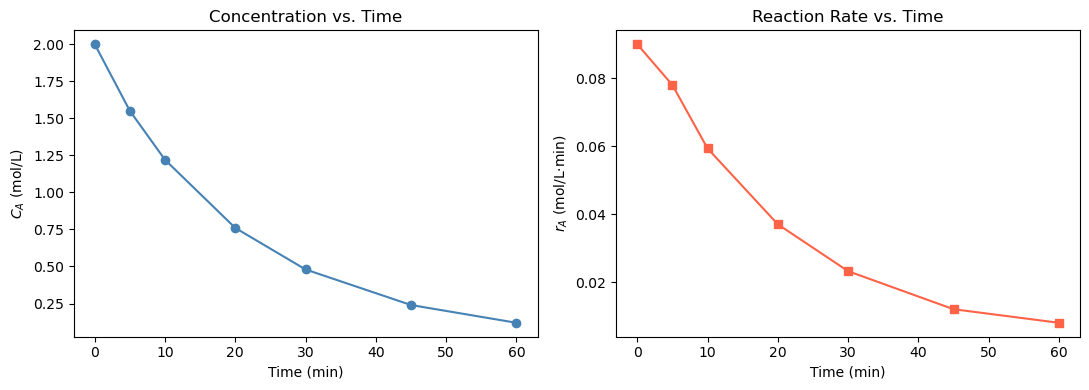

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid

t_rxn = np.array([0,    5,    10,   20,   30,   45,   60  ])  # min
C_A   = np.array([2.00, 1.55, 1.22, 0.76, 0.48, 0.24, 0.12])  # mol/L

# (a) Compute reaction rate
r_A = TODO

print(f"{'t (min)':>8}  {'C_A (mol/L)':>12}  {'r_A (mol/L·min)':>16}")
print("-" * 42)
for i in range(len(t_rxn)):
    print(f"  {t_rxn[i]:>6.0f}  {C_A[i]:>12.2f}  {r_A[i]:>16.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_rxn, C_A, 'o-', color='steelblue')
axes[0].set_xlabel('Time (min)')
axes[0].set_ylabel('$C_A$ (mol/L)')
axes[0].set_title('Concentration vs. Time')

axes[1].plot(t_rxn, r_A, 's-', color='tomato')
axes[1].set_xlabel('Time (min)')
axes[1].set_ylabel('$r_A$ (mol/L·min)')
axes[1].set_title('Reaction Rate vs. Time')

plt.tight_layout()
plt.show()

**(b)** Recompute $r_A$ using only NumPy array operations — **no `np.gradient`**. Use:
- a **forward difference** at the first point: $\displaystyle\left.\frac{dC_A}{dt}\right|_0 \approx \frac{C_{A,1} - C_{A,0}}{t_1 - t_0}$
- **central differences** at interior points: $\displaystyle\left.\frac{dC_A}{dt}\right|_i \approx \frac{C_{A,i+1} - C_{A,i-1}}{t_{i+1} - t_{i-1}}$
- a **backward difference** at the last point: $\displaystyle\left.\frac{dC_A}{dt}\right|_{-1} \approx \frac{C_{A,-1} - C_{A,-2}}{t_{-1} - t_{-2}}$

Print a table of $t$, $C_A$, and $r_A$. Note: the endpoint values will differ slightly from part (a) because `np.gradient` uses a higher-order one-sided formula at the boundaries.

In [20]:
# (b) Compute r_A using numpy array operations (no np.gradient)
dCdt = np.zeros(len(t_rxn))

# Forward difference at the first point
dCdt[0] = (C_A[1] - C_A[0]) / (t_rxn[1] - t_rxn[0])


# Central differences at interior points
dCdt[1:-1] = (C_A[2:] - C_A[:-2]) / (t_rxn[2:] - t_rxn[:-2])

# Backward difference at the last point
dCdt[-1] = (C_A[-1] - C_A[-2]) / (t_rxn[-1] - t_rxn[-2])

r_A_manual = -dCdt

print(f"{'t (min)':>8}  {'C_A (mol/L)':>12}  {'r_A (mol/L·min)':>16}")
print("-" * 42)
for i in range(len(t_rxn)):
    print(f"  {t_rxn[i]:>6.0f}  {C_A[i]:>12.2f}  {r_A_manual[i]:>16.4f}")

 t (min)   C_A (mol/L)   r_A (mol/L·min)
------------------------------------------
       0          2.00            0.0900
       5          1.55            0.0780
      10          1.22            0.0527
      20          0.76            0.0370
      30          0.48            0.0208
      45          0.24            0.0120
      60          0.12            0.0080


**(c)** To determine the reaction order, plot $\ln(r_A)$ vs. $\ln(C_A)$ and determine the correlation between them. Estimate the reaction order $n$ by calculating the slope.

Estimated reaction order: n = 0.90


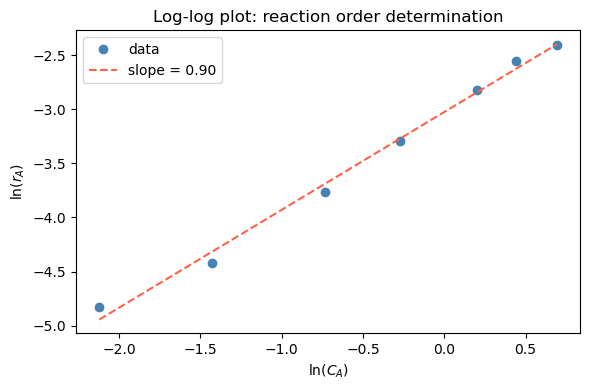

In [21]:
# (c) Log-log plot to determine reaction order
coeffs = np.polyfit(np.log(C_A), np.log(r_A), 1)
n = coeffs[0]
print(f"Estimated reaction order: n = {n:.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(np.log(C_A), np.log(r_A), 'o', color='steelblue', label='data')
ln_C_fit = np.linspace(np.log(C_A.min()), np.log(C_A.max()), 100)
ax.plot(ln_C_fit, np.polyval(coeffs, ln_C_fit), '--', color='tomato', label=f'slope = {n:.2f}')
ax.set_xlabel('ln($C_A$)')
ax.set_ylabel('ln($r_A$)')
ax.set_title('Log-log plot: reaction order determination')
ax.legend()
plt.tight_layout()
plt.show()

### Problem 2: PFR Design — Levenspiel Integration

A plug flow reactor processes species A via a first-order liquid-phase reaction:

$$-r_A = k C_{A0}(1 - X), \qquad k = 0.12 \text{ min}^{-1}, \quad C_{A0} = 1.5 \text{ mol/L}, \quad F_{A0} = 3.0 \text{ mol/min}$$

The design equation is:

$$V = F_{A0} \int_0^{X_f} \frac{dX}{-r_A(X)}$$

The analytical solution for a first-order PFR is $V = \dfrac{F_{A0}}{k C_{A0}} \ln\!\left(\dfrac{1}{1-X_f}\right)$.

**(a)** Define `levenspiel(X)` = $1/(-r_A(X))$ and use `quad` to compute $V$ for $X_f = 0.90$. Compare to the analytical answer and print the relative error.

V (quad):       38.3764 L
V (analytical): 38.3764 L
Relative error: 2.78e-15


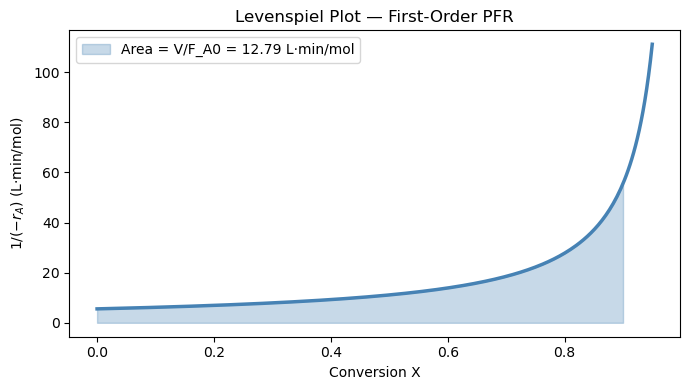

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, trapezoid, cumulative_trapezoid

k    = 0.12    # 1/min
C_A0 = 1.5     # mol/L
F_A0 = 3.0     # mol/min
X_f  = 0.90

def rate_1st(X):
    return k * C_A0 * (1 - X)

def levenspiel_1st(X):
    return 1.0 / rate_1st(X)

# (a) quad integration
integral, err = quad(levenspiel_1st, 0, X_f)
V_quad = F_A0 * integral

# Analytical answer
V_exact = (F_A0 / (k * C_A0)) * np.log(1 / (1 - X_f))

print(f"V (quad):       {V_quad:.4f} L")
print(f"V (analytical): {V_exact:.4f} L")
print(f"Relative error: {abs(V_quad - V_exact)/V_exact:.2e}")

X_plot = np.linspace(0, 0.95, 300)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X_plot, levenspiel_1st(X_plot), 'steelblue', linewidth=2.5)

X_shade = np.linspace(0, X_f, 300)
ax.fill_between(X_shade, levenspiel_1st(X_shade), alpha=0.3, color='steelblue',
                label=f'Area = V/F_A0 = {V_quad/F_A0:.2f} L·min/mol')

ax.set_xlabel('Conversion X')
ax.set_ylabel('$1 / (-r_A)$ (L·min/mol)')
ax.set_title('Levenspiel Plot — First-Order PFR')
ax.legend()
plt.tight_layout()
plt.show()